In [1]:
!pip install -q opendatasets torch torchvision matplotlib seaborn scikit-learn tqdm

import os, gc, time, copy, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import confusion_matrix
import opendatasets as od

print("✅ Imports done")

✅ Imports done


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
dataset_url = "https://www.kaggle.com/datasets/sshikamaru/fruit-recognition"
od.download(dataset_url)

data_dir = "./fruit-recognition"
print("Dataset downloaded to:", data_dir)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: allencristianmanzo
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sshikamaru/fruit-recognition


100%|██████████| 102M/102M [00:00<00:00, 1.65GB/s]

Dataset downloaded to: ./fruit-recognition


In [4]:
# ------------------------------------------------------------
# 1. Base dataset directory
# ------------------------------------------------------------
base_dir = './fruit-recognition'

# ------------------------------------------------------------
# 2. Locate the real train folder (which contains class folders)
# ------------------------------------------------------------
train_candidates = [
    os.path.join(base_dir, 'train', 'train'),   # most common in this dataset
    os.path.join(base_dir, 'train'),            # fallback
]

real_train_dir = None
for cand in train_candidates:
    if os.path.exists(cand):
        # Check if it contains subdirectories (classes)
        subdirs = [d for d in os.listdir(cand)
                   if os.path.isdir(os.path.join(cand, d))]
        if subdirs:
            real_train_dir = cand
            print(f"✅ Train folder found: {real_train_dir}")
            print(f"   Sample classes: {subdirs[:5]}")
            break

if real_train_dir is None:
    raise FileNotFoundError("Could not locate train folder with class subdirectories.")

# ------------------------------------------------------------
# 3. Locate the real test folder (which contains class folders)
# ------------------------------------------------------------
test_candidates = [
    os.path.join(base_dir, 'test', 'test'),
    os.path.join(base_dir, 'test'),
]

real_test_dir = None
for cand in test_candidates:
    if os.path.exists(cand):
        subdirs = [d for d in os.listdir(cand)
                   if os.path.isdir(os.path.join(cand, d))]
        if subdirs:
            real_test_dir = cand
            print(f"✅ Test folder found: {real_test_dir}")
            print(f"   Sample classes: {subdirs[:5]}")
            break

if real_test_dir is None:
    raise FileNotFoundError("Could not locate test folder with class subdirectories.")

✅ Train folder found: ./fruit-recognition/train/train
   Sample classes: ['Corn', 'Pomegranate', 'Cantaloupe', 'Tomato', 'Kiwi']
✅ Test folder found: ./fruit-recognition/test
   Sample classes: ['test']


In [5]:
# Get class names from train
train_classes = [d for d in os.listdir(real_train_dir)
                 if os.path.isdir(os.path.join(real_train_dir, d))]

# Get class names from test
test_classes = [d for d in os.listdir(real_test_dir)
                if os.path.isdir(os.path.join(real_test_dir, d))]

# Union of both
all_classes = sorted(set(train_classes).union(set(test_classes)))
print(f"Total unique classes in dataset: {len(all_classes)}")
print("First 20:", all_classes[:20])

Total unique classes in dataset: 34
First 20: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya']


In [6]:
# 🔧 YOU CAN EDIT THIS LIST to any 5 classes present above
selected_classes = ['Mango', 'Banana', 'Pineapple', 'Watermelon', 'Corn']

# Verify all are in the dataset
for cls in selected_classes:
    if cls not in all_classes:
        raise ValueError(f"Class '{cls}' not found in dataset! Available: {all_classes[:10]}...")

print("✅ Selected classes:")
for i, cls in enumerate(selected_classes):
    print(f"   {i}: {cls}")

class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}
idx_to_class = {i: cls for i, cls in enumerate(selected_classes)}

✅ Selected classes:
   0: Mango
   1: Banana
   2: Pineapple
   3: Watermelon
   4: Corn


In [7]:
all_image_paths = []
all_labels = []

# Walk through the REAL train folder
for root, dirs, files in os.walk(real_train_dir):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            label = os.path.basename(root)
            if label in selected_classes:
                all_image_paths.append(os.path.join(root, file))
                all_labels.append(class_to_idx[label])

# Walk through the REAL test folder
for root, dirs, files in os.walk(real_test_dir):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            label = os.path.basename(root)
            if label in selected_classes:
                all_image_paths.append(os.path.join(root, file))
                all_labels.append(class_to_idx[label])

print(f"Total images collected: {len(all_image_paths)}")

Total images collected: 2395


In [8]:
class_paths = {cls: [] for cls in selected_classes}
for path, lbl in zip(all_image_paths, all_labels):
    class_paths[idx_to_class[lbl]].append(path)

print("Images per class (total available):")
for cls in selected_classes:
    count = len(class_paths[cls])
    print(f"  {cls}: {count} images")
    if count < 100:
        print(f"    ⚠️  Only {count} images – will use fewer per split.")

Images per class (total available):
  Mango: 490 images
  Banana: 490 images
  Pineapple: 490 images
  Watermelon: 475 images
  Corn: 450 images


In [9]:
NUM_CLASSES = len(selected_classes)
NUM_RUNS = 5                # multi‑run averaging
EPOCHS = 20
BATCH_SIZE = 32
LR = 0.001
MOMENTUM = 0.9
STEP_SIZE = 7
GAMMA = 0.1

# Small‑dataset simulation
TRAIN_PER_CLASS = 50
VAL_PER_CLASS   = 15
TEST_PER_CLASS  = 35

IMG_SIZE = 224

print("Hyperparameters set.")

Hyperparameters set.


In [10]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms ready.")

Transforms ready.


In [11]:
def create_run_dataset(run_seed, base_dir='/content/run_data'):
    """
    Creates train/val/test directories by COPYING images.
    Returns three ImageFolder datasets.
    """
    run_dir = os.path.join(base_dir, f'run_{run_seed}')
    train_dir = os.path.join(run_dir, 'train')
    val_dir   = os.path.join(run_dir, 'val')
    test_dir  = os.path.join(run_dir, 'test')

    # Remove old run directory if exists
    if os.path.exists(run_dir):
        shutil.rmtree(run_dir)

    # Create empty directories
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir,   exist_ok=True)
    os.makedirs(test_dir,  exist_ok=True)

    # For each class, sample and copy images
    for cls in selected_classes:
        paths = class_paths[cls]
        random.Random(run_seed).shuffle(paths)

        n_train = min(TRAIN_PER_CLASS, len(paths))
        n_val   = min(VAL_PER_CLASS,   len(paths) - n_train)
        n_test  = min(TEST_PER_CLASS,  len(paths) - n_train - n_val)

        train_paths = paths[:n_train]
        val_paths   = paths[n_train:n_train+n_val]
        test_paths  = paths[n_train+n_val:n_train+n_val+n_test]

        # Create class subfolders
        os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
        os.makedirs(os.path.join(val_dir,   cls), exist_ok=True)
        os.makedirs(os.path.join(test_dir,  cls), exist_ok=True)

        # Copy images (not symlink) – guaranteed to work
        for src in train_paths:
            dst = os.path.join(train_dir, cls, os.path.basename(src))
            shutil.copy(src, dst)
        for src in val_paths:
            dst = os.path.join(val_dir, cls, os.path.basename(src))
            shutil.copy(src, dst)
        for src in test_paths:
            dst = os.path.join(test_dir, cls, os.path.basename(src))
            shutil.copy(src, dst)

    # Create PyTorch datasets
    train_dataset = ImageFolder(train_dir, transform=train_transform)
    val_dataset   = ImageFolder(val_dir,   transform=val_test_transform)
    test_dataset  = ImageFolder(test_dir,  transform=val_test_transform)

    return train_dataset, val_dataset, test_dataset

In [12]:
# Quick test: create one run and inspect folders
test_ds, _, _ = create_run_dataset(9999)
print("✅ Dataset created successfully.")
print(f"Classes: {test_ds.classes}")
print(f"Number of training images: {len(test_ds)}")

✅ Dataset created successfully.
Classes: ['Banana', 'Corn', 'Mango', 'Pineapple', 'Watermelon']
Number of training images: 250


In [13]:
def create_model(pretrained=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, NUM_CLASSES)
    return model.to(device)

print("Model factory ready.")

Model factory ready.


In [14]:
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = validate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    training_time = time.time() - start_time
    model.load_state_dict(best_model_wts)
    return model, history, training_time

def evaluate(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

print("Training functions ready.")

Training functions ready.


In [15]:
# %% [markdown]
# ## 14. Optimized Multi‑Run Experiment with Mixed Precision (AMP)

# %%
# ------------------------------------------------------------
# 0. IMPORT MISSING AMP COMPONENTS
# ------------------------------------------------------------
from torch.cuda.amp import autocast, GradScaler

# ------------------------------------------------------------
# 1. AMP‑enabled training function (replaces old train_model)
# ------------------------------------------------------------
def train_model_amp(model, train_loader, val_loader, epochs, scaler):
    """Training loop with Automatic Mixed Precision (AMP) for 2–3x speedup."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    start_time = time.time()

    for epoch in range(epochs):
        # ----- Training with AMP -----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ----- Validation (no AMP needed) -----
        val_loss, val_acc = validate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # 👀 Live progress – Colab won't look frozen
        print(f"  Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    training_time = time.time() - start_time
    model.load_state_dict(best_model_wts)
    return model, history, training_time


# ------------------------------------------------------------
# 2. Multi‑Run Experiment (5 runs, each with pretrained + scratch)
# ------------------------------------------------------------
results = {
    'pretrained': {'histories': [], 'test_acc': [], 'cm': [], 'time': []},
    'scratch':    {'histories': [], 'test_acc': [], 'cm': [], 'time': []}
}

base_seed = 12345
scaler = GradScaler()  # for mixed precision

for run in range(NUM_RUNS):
    print(f"\n{'='*50}\nRUN {run+1}/{NUM_RUNS}\n{'='*50}")
    run_seed = base_seed + run
    set_seed(run_seed)

    # ---- Create dataset for this run ----
    train_dataset, val_dataset, test_dataset = create_run_dataset(run_seed)

    # ⚡ num_workers=0 – no more Colab hanging
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # ---- Pretrained model ----
    print("\n--- Training Pretrained ResNet18 ---")
    model_pre = create_model(pretrained=True)
    model_pre, history_pre, time_pre = train_model_amp(model_pre, train_loader, val_loader, EPOCHS, scaler)

    test_labels, test_preds_pre = evaluate(model_pre, test_loader)
    test_acc_pre = (test_preds_pre == test_labels).mean()
    cm_pre = confusion_matrix(test_labels, test_preds_pre)

    results['pretrained']['histories'].append(history_pre)
    results['pretrained']['test_acc'].append(test_acc_pre)
    results['pretrained']['cm'].append(cm_pre)
    results['pretrained']['time'].append(time_pre)

    # ---- Scratch model (random init) ----
    print("\n--- Training from Scratch (Random Init) ---")
    model_scratch = create_model(pretrained=False)
    model_scratch, history_scratch, time_scratch = train_model_amp(model_scratch, train_loader, val_loader, EPOCHS, scaler)

    _, test_preds_scratch = evaluate(model_scratch, test_loader)
    test_acc_scratch = (test_preds_scratch == test_labels).mean()
    cm_scratch = confusion_matrix(test_labels, test_preds_scratch)

    results['scratch']['histories'].append(history_scratch)
    results['scratch']['test_acc'].append(test_acc_scratch)
    results['scratch']['cm'].append(cm_scratch)
    results['scratch']['time'].append(time_scratch)

    # ---- Cleanup ----
    del model_pre, model_scratch, train_dataset, val_dataset, test_dataset
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ All 5 runs completed!")


RUN 1/5

--- Training Pretrained ResNet18 ---


/tmp/ipython-input-3860245824.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # for mixed precision


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 123MB/s]
/tmp/ipython-input-3860245824.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 1/20 - Train Acc: 0.5400, Val Acc: 0.9867
  Epoch 2/20 - Train Acc: 0.9760, Val Acc: 1.0000
  Epoch 3/20 - Train Acc: 0.9960, Val Acc: 1.0000
  Epoch 4/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 5/20 - Train Acc: 0.9920, Val Acc: 1.0000
  Epoch 6/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 7/20 - Train Acc: 0.9960, Val Acc: 1.0000
  Epoch 8/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 9/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 10/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 11/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 12/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 13/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 14/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 15/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 16/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 17/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 18/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 19/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 20/20 - Train Acc: 1.0000, Val A

...

  Epoch 1/20 - Train Acc: 0.3400, Val Acc: 0.3067
  Epoch 2/20 - Train Acc: 0.7040, Val Acc: 0.6000
  Epoch 3/20 - Train Acc: 0.8400, Val Acc: 0.6667
  Epoch 4/20 - Train Acc: 0.9520, Val Acc: 0.9600
  Epoch 5/20 - Train Acc: 0.9440, Val Acc: 0.9733
  Epoch 6/20 - Train Acc: 0.9520, Val Acc: 0.9733
  Epoch 7/20 - Train Acc: 0.9560, Val Acc: 0.9733
  Epoch 8/20 - Train Acc: 0.9680, Val Acc: 1.0000
  Epoch 9/20 - Train Acc: 0.9920, Val Acc: 1.0000
  Epoch 10/20 - Train Acc: 0.9920, Val Acc: 0.9733
  Epoch 11/20 - Train Acc: 0.9800, Val Acc: 0.9733
  Epoch 12/20 - Train Acc: 0.9840, Val Acc: 0.9867
  Epoch 13/20 - Train Acc: 0.9920, Val Acc: 0.9867
  Epoch 14/20 - Train Acc: 0.9880, Val Acc: 0.9867
  Epoch 15/20 - Train Acc: 0.9960, Val Acc: 0.9867
  Epoch 16/20 - Train Acc: 0.9960, Val Acc: 0.9867
  Epoch 17/20 - Train Acc: 0.9840, Val Acc: 0.9867
  Epoch 18/20 - Train Acc: 0.9880, Val Acc: 1.0000
  Epoch 19/20 - Train Acc: 0.9880, Val Acc: 1.0000
  Epoch 20/20 - Train Acc: 0.9920, Val A

/tmp/ipython-input-3860245824.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 1/20 - Train Acc: 0.5760, Val Acc: 0.9333
  Epoch 2/20 - Train Acc: 0.9920, Val Acc: 1.0000
  Epoch 3/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 4/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 5/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 6/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 7/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 8/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 9/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 10/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 11/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 12/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 13/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 14/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 15/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 16/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 17/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 18/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 19/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 20/20 - Train Acc: 1.0000, Val A

/tmp/ipython-input-3860245824.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 1/20 - Train Acc: 0.2840, Val Acc: 0.4400
  Epoch 2/20 - Train Acc: 0.5720, Val Acc: 0.6133
  Epoch 3/20 - Train Acc: 0.7960, Val Acc: 0.6000
  Epoch 4/20 - Train Acc: 0.8800, Val Acc: 0.6667
  Epoch 5/20 - Train Acc: 0.9840, Val Acc: 0.8667
  Epoch 6/20 - Train Acc: 0.9840, Val Acc: 1.0000
  Epoch 7/20 - Train Acc: 0.9840, Val Acc: 1.0000
  Epoch 8/20 - Train Acc: 0.9920, Val Acc: 1.0000
  Epoch 9/20 - Train Acc: 0.9840, Val Acc: 1.0000
  Epoch 10/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 11/20 - Train Acc: 0.9880, Val Acc: 1.0000
  Epoch 12/20 - Train Acc: 0.9800, Val Acc: 1.0000
  Epoch 13/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 14/20 - Train Acc: 0.9920, Val Acc: 1.0000
  Epoch 15/20 - Train Acc: 0.9840, Val Acc: 1.0000
  Epoch 16/20 - Train Acc: 0.9920, Val Acc: 1.0000
  Epoch 17/20 - Train Acc: 0.9920, Val Acc: 1.0000
  Epoch 18/20 - Train Acc: 0.9880, Val Acc: 1.0000
  Epoch 19/20 - Train Acc: 1.0000, Val Acc: 1.0000
  Epoch 20/20 - Train Acc: 0.9920, Val A

In [16]:
def aggregate_histories(histories):
    epochs = len(histories[0]['train_loss'])
    agg = {}
    for metric in ['train_loss', 'train_acc', 'val_loss', 'val_acc']:
        values = np.array([h[metric] for h in histories])  # (runs, epochs)
        agg[metric + '_mean'] = np.mean(values, axis=0)
        agg[metric + '_std'] = np.std(values, axis=0)
    return agg


pretrained_agg = aggregate_histories(results['pretrained']['histories'])
scratch_agg = aggregate_histories(results['scratch']['histories'])

pretrained_test_mean = np.mean(results['pretrained']['test_acc'])
pretrained_test_std = np.std(results['pretrained']['test_acc'])
scratch_test_mean = np.mean(results['scratch']['test_acc'])
scratch_test_std = np.std(results['scratch']['test_acc'])

pretrained_time_mean = np.mean(results['pretrained']['time'])
pretrained_time_std = np.std(results['pretrained']['time'])
scratch_time_mean = np.mean(results['scratch']['time'])
scratch_time_std = np.std(results['scratch']['time'])

print("=== Average Test Accuracy ===")
print(f"Pretrained: {pretrained_test_mean:.4f} ± {pretrained_test_std:.4f}")
print(f"Scratch:    {scratch_test_mean:.4f} ± {scratch_test_std:.4f}")


=== Average Test Accuracy ===
Pretrained: 1.0000 ± 0.0000
Scratch:    0.9954 ± 0.0091


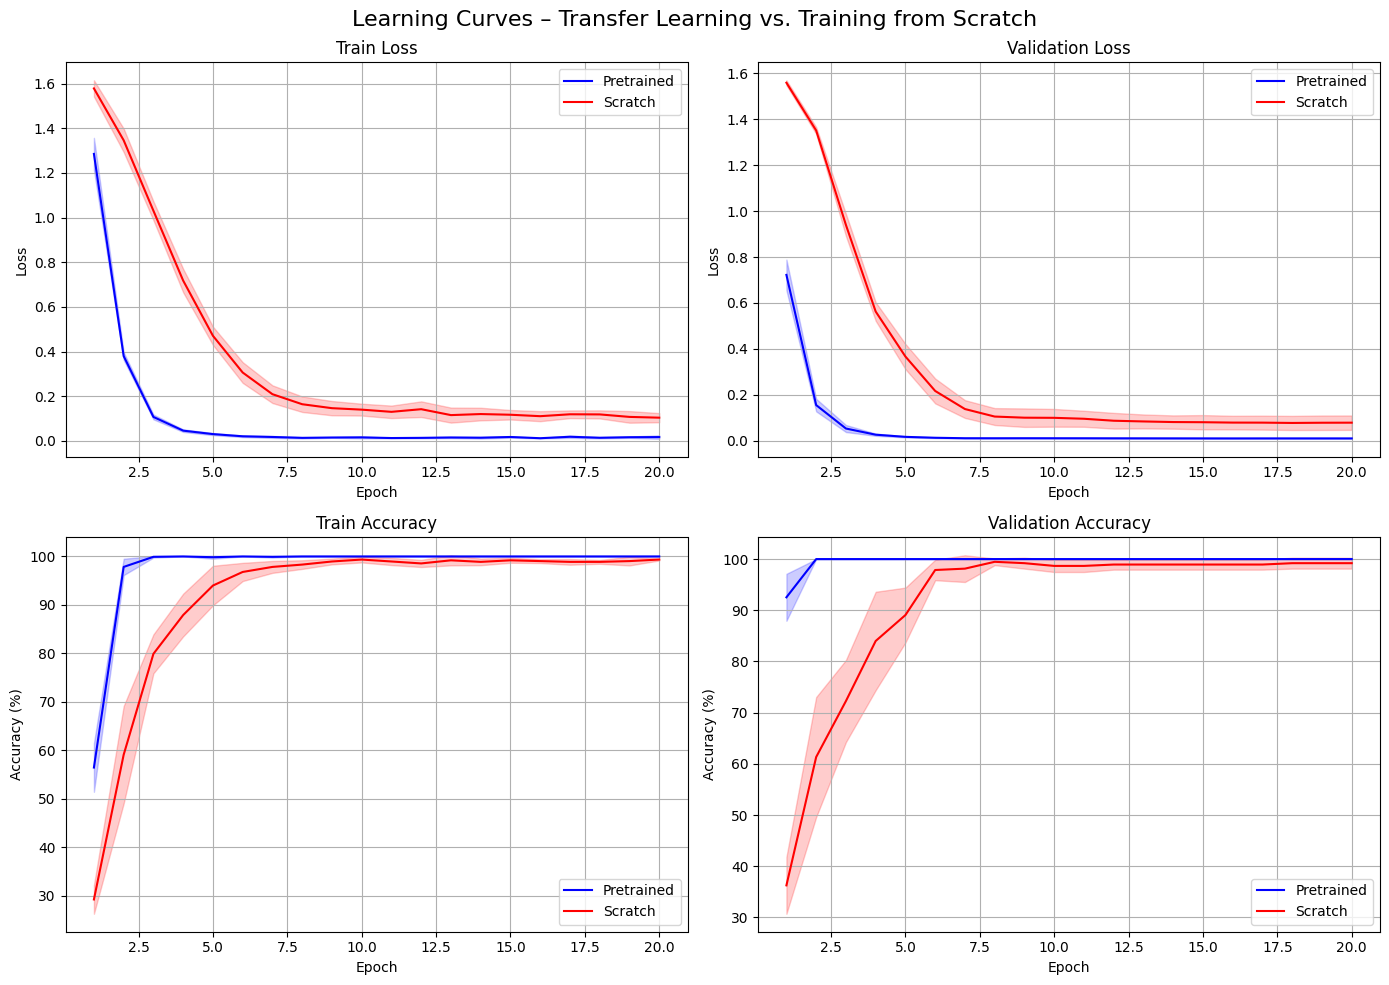

In [17]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Learning Curves – Transfer Learning vs. Training from Scratch", fontsize=16)

# Train Loss
ax = axes[0, 0]
ax.plot(epochs_range, pretrained_agg["train_loss_mean"], "b-", label="Pretrained")
ax.fill_between(
    epochs_range,
    pretrained_agg["train_loss_mean"] - pretrained_agg["train_loss_std"],
    pretrained_agg["train_loss_mean"] + pretrained_agg["train_loss_std"],
    alpha=0.2,
    color="b",
)
ax.plot(epochs_range, scratch_agg["train_loss_mean"], "r-", label="Scratch")
ax.fill_between(
    epochs_range,
    scratch_agg["train_loss_mean"] - scratch_agg["train_loss_std"],
    scratch_agg["train_loss_mean"] + scratch_agg["train_loss_std"],
    alpha=0.2,
    color="r",
)
ax.set_title("Train Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)

# Validation Loss
ax = axes[0, 1]
ax.plot(epochs_range, pretrained_agg["val_loss_mean"], "b-", label="Pretrained")
ax.fill_between(
    epochs_range,
    pretrained_agg["val_loss_mean"] - pretrained_agg["val_loss_std"],
    pretrained_agg["val_loss_mean"] + pretrained_agg["val_loss_std"],
    alpha=0.2,
    color="b",
)
ax.plot(epochs_range, scratch_agg["val_loss_mean"], "r-", label="Scratch")
ax.fill_between(
    epochs_range,
    scratch_agg["val_loss_mean"] - scratch_agg["val_loss_std"],
    scratch_agg["val_loss_mean"] + scratch_agg["val_loss_std"],
    alpha=0.2,
    color="r",
)
ax.set_title("Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)

# Train Accuracy
ax = axes[1, 0]
ax.plot(epochs_range, pretrained_agg["train_acc_mean"] * 100, "b-", label="Pretrained")
ax.fill_between(
    epochs_range,
    (pretrained_agg["train_acc_mean"] - pretrained_agg["train_acc_std"]) * 100,
    (pretrained_agg["train_acc_mean"] + pretrained_agg["train_acc_std"]) * 100,
    alpha=0.2,
    color="b",
)
ax.plot(epochs_range, scratch_agg["train_acc_mean"] * 100, "r-", label="Scratch")
ax.fill_between(
    epochs_range,
    (scratch_agg["train_acc_mean"] - scratch_agg["train_acc_std"]) * 100,
    (scratch_agg["train_acc_mean"] + scratch_agg["train_acc_std"]) * 100,
    alpha=0.2,
    color="r",
)
ax.set_title("Train Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.legend()
ax.grid(True)

# Validation Accuracy
ax = axes[1, 1]
ax.plot(epochs_range, pretrained_agg["val_acc_mean"] * 100, "b-", label="Pretrained")
ax.fill_between(
    epochs_range,
    (pretrained_agg["val_acc_mean"] - pretrained_agg["val_acc_std"]) * 100,
    (pretrained_agg["val_acc_mean"] + pretrained_agg["val_acc_std"]) * 100,
    alpha=0.2,
    color="b",
)
ax.plot(epochs_range, scratch_agg["val_acc_mean"] * 100, "r-", label="Scratch")
ax.fill_between(
    epochs_range,
    (scratch_agg["val_acc_mean"] - scratch_agg["val_acc_std"]) * 100,
    (scratch_agg["val_acc_mean"] + scratch_agg["val_acc_std"]) * 100,
    alpha=0.2,
    color="r",
)
ax.set_title("Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


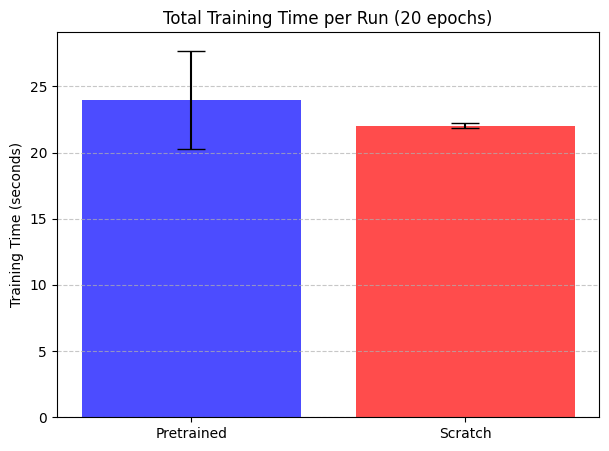

Pretrained: 23.97 ± 3.73 s
Scratch:    22.03 ± 0.19 s


In [18]:
labels = ["Pretrained", "Scratch"]
times_mean = [pretrained_time_mean, scratch_time_mean]
times_std = [pretrained_time_std, scratch_time_std]

plt.figure(figsize=(7, 5))
plt.bar(labels, times_mean, yerr=times_std, capsize=10, color=["blue", "red"], alpha=0.7)
plt.ylabel("Training Time (seconds)")
plt.title("Total Training Time per Run (20 epochs)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print(f"Pretrained: {pretrained_time_mean:.2f} ± {pretrained_time_std:.2f} s")
print(f"Scratch:    {scratch_time_mean:.2f} ± {scratch_time_std:.2f} s")


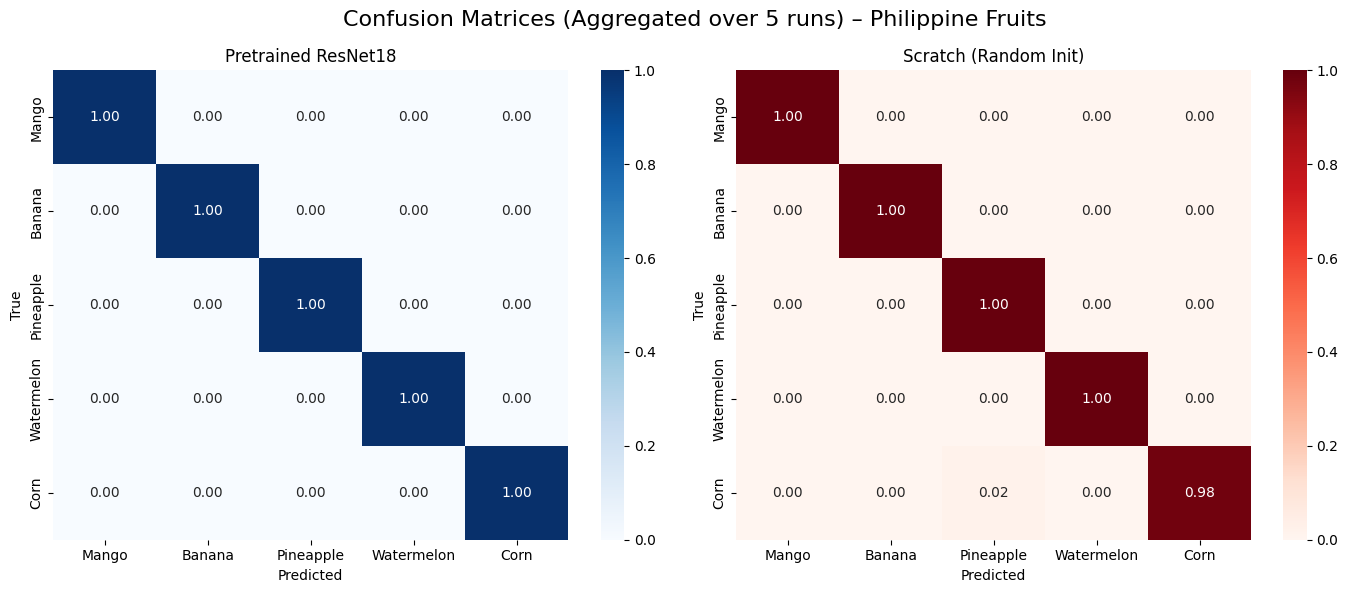

In [19]:
pretrained_cm_sum = np.sum(results["pretrained"]["cm"], axis=0)
scratch_cm_sum = np.sum(results["scratch"]["cm"], axis=0)

pretrained_cm_norm = pretrained_cm_sum.astype("float") / pretrained_cm_sum.sum(axis=1)[:, np.newaxis]
scratch_cm_norm = scratch_cm_sum.astype("float") / scratch_cm_sum.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Confusion Matrices (Aggregated over 5 runs) – Philippine Fruits", fontsize=16)

sns.heatmap(
    pretrained_cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=selected_classes,
    yticklabels=selected_classes,
    ax=axes[0],
)
axes[0].set_title("Pretrained ResNet18")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    scratch_cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    xticklabels=selected_classes,
    yticklabels=selected_classes,
    ax=axes[1],
)
axes[1].set_title("Scratch (Random Init)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


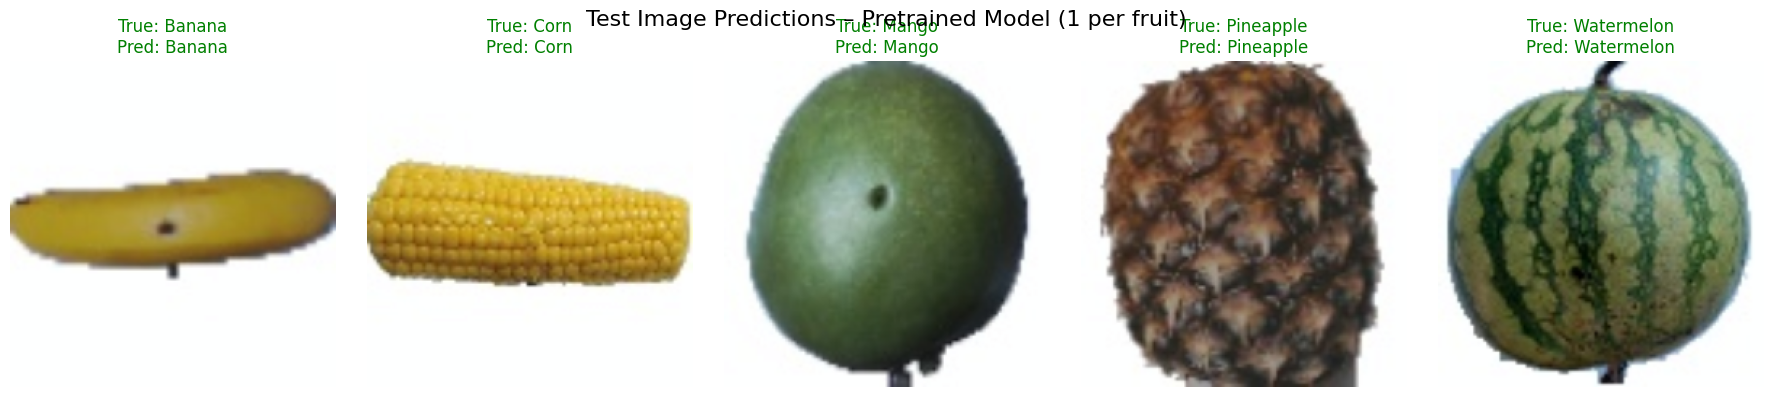

In [27]:

import random
from collections import defaultdict
from torch.utils.data import Subset, DataLoader

# 1) Correct mapping from your ImageFolder test dataset
test_dataset = test_loader.dataset
idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}

# 2) Pick 1 image index per class (so you will show all 5 fruits)
by_class = defaultdict(list)
for i, (_, y) in enumerate(test_dataset.samples):
    by_class[y].append(i)

rng = random.Random(0)  # reproducible
chosen_indices = [rng.choice(by_class[c]) for c in range(len(test_dataset.classes))]

# 3) Load those 5 images as one batch
subset = Subset(test_dataset, chosen_indices)
subset_loader = DataLoader(subset, batch_size=len(chosen_indices), shuffle=False)
images, labels = next(iter(subset_loader))

# 4) Predict + plot
model_pre.eval()
with torch.no_grad():
    outputs = model_pre(images.to(device))
    preds = outputs.argmax(dim=1).detach().cpu()

plt.figure(figsize=(18, 4))
for i in range(len(chosen_indices)):
    plt.subplot(1, len(chosen_indices), i + 1)

    true_label = idx_to_class[int(labels[i].item())]
    pred_label = idx_to_class[int(preds[i].item())]
    color = "green" if true_label == pred_label else "red"

    imshow(images[i], title=f"True: {true_label}\nPred: {pred_label}")
    plt.gca().title.set_color(color)

plt.suptitle("Test Image Predictions – Pretrained Model (1 per fruit)", fontsize=16)
plt.tight_layout()
plt.show()


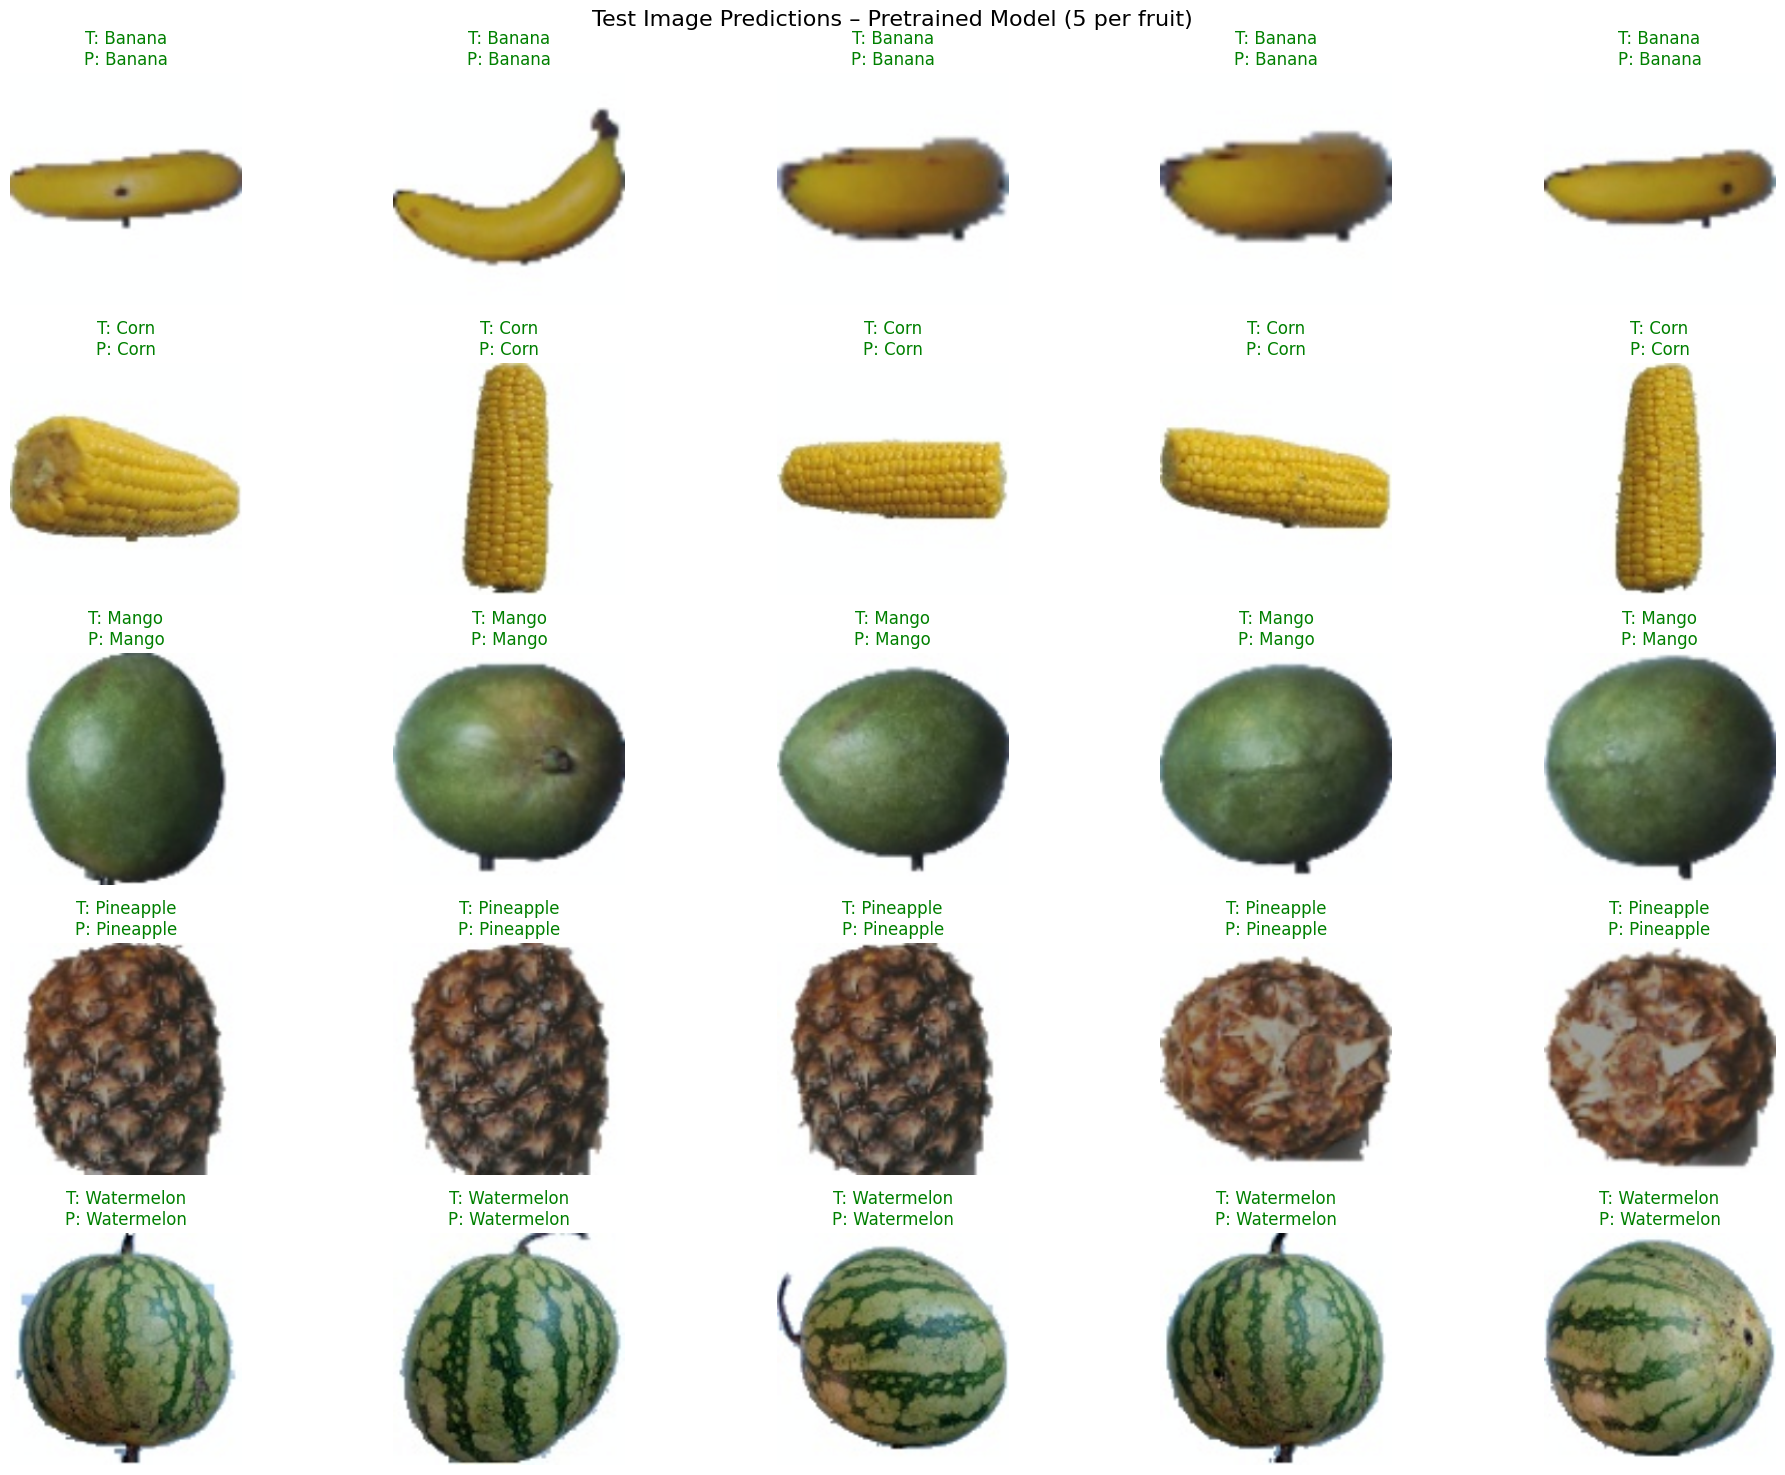

In [29]:
import random
from collections import defaultdict
from torch.utils.data import Subset, DataLoader

# Dataset + correct label mapping
test_dataset = test_loader.dataset
idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}
num_classes = len(test_dataset.classes)

# Collect indices per class
by_class = defaultdict(list)
for i, (_, y) in enumerate(test_dataset.samples):
    by_class[y].append(i)

# Pick 5 indices per class (or fewer if not enough images)
rng = random.Random(0)
k = 5
chosen_indices = []
for c in range(num_classes):
    candidates = by_class[c]
    take = min(k, len(candidates))
    chosen_indices.extend(rng.sample(candidates, take))

# Load selected images
subset = Subset(test_dataset, chosen_indices)
subset_loader = DataLoader(subset, batch_size=len(chosen_indices), shuffle=False)
images, labels = next(iter(subset_loader))

# Predict
model_pre.eval()
with torch.no_grad():
    outputs = model_pre(images.to(device))
    preds = outputs.argmax(dim=1).detach().cpu()

# Plot in a grid: rows=classes, cols=5
rows = num_classes
cols = k
plt.figure(figsize=(cols * 4, rows * 3))

for i in range(len(chosen_indices)):
    plt.subplot(rows, cols, i + 1)

    true_label = idx_to_class[int(labels[i].item())]
    pred_label = idx_to_class[int(preds[i].item())]
    color = "green" if true_label == pred_label else "red"

    imshow(images[i], title=f"T: {true_label}\nP: {pred_label}")
    plt.gca().title.set_color(color)

plt.suptitle("Test Image Predictions – Pretrained Model (5 per fruit)", fontsize=16)
plt.tight_layout()
plt.show()


In [28]:
print("=" * 60)
print("EXPERIMENT COMPLETED – FULLY REPRODUCIBLE")
print("=" * 60)
print(f"• Random seeds: base_seed = {base_seed}, {NUM_RUNS} runs")
print("• Deterministic CUDA enabled")
print(f"• Classes used: {selected_classes}")
print(f"• Training images per class: {TRAIN_PER_CLASS}")
print(f"• Validation images per class: {VAL_PER_CLASS}")
print(f"• Test images per class: {TEST_PER_CLASS}")
print("• All hyperparameters explicitly defined")
print("• Dataset copying used – 100% reliable on Colab")
print("=" * 60)


EXPERIMENT COMPLETED – FULLY REPRODUCIBLE
• Random seeds: base_seed = 12345, 5 runs
• Deterministic CUDA enabled
• Classes used: ['Mango', 'Banana', 'Pineapple', 'Watermelon', 'Corn']
• Training images per class: 50
• Validation images per class: 15
• Test images per class: 35
• All hyperparameters explicitly defined
• Dataset copying used – 100% reliable on Colab
